In [3]:
suppressPackageStartupMessages({
    library(patchwork)
    library(Seurat)
library(scCustomize)
library(spatula)
library(ComplexHeatmap)
    library(rcna)
    library(circlize)
    library(ggrastr)
    library(tidyverse)
    library(scico)
    library(circlize)
    library(ggsci)
    })

library(ggrastr)

get_theme <- function(size=12, angle=45) {
    defined_theme = theme_bw(base_size=size) + theme(legend.title=element_blank(), strip.text=element_text(size=size), legend.text=element_text(size=size), axis.title.x=element_text(size=size), axis.title.y=element_text(size=size), axis.text.y=element_text(size=size), axis.text.x=element_text(size=size, angle=angle, hjust = 1, vjust=1.05), legend.position="bottom", legend.box = "horizontal")
    defined_theme
}

fig.size <- function(h, w) {
    options(repr.plot.height = h, repr.plot.width = w)
}

In [4]:
niche_cols = c(
  # Immune (purples)
  "Immune"              = "#6a51a3",  # medium-deep purple

  # Myeloid / Skeletal Muscle (yellows/oranges)
  #"Skeletal Muscle"      = "#fdcc8a",  # warm orange-yellow

  # Endothelial / Fibrosis (blues)
  "Fibrosis & Interstitium" = "#6baed6",  # light sky blue
  "Vessel"                 = "#08519c",  # deep blue

  # Kidney cells (reds → pinks → violets, smooth gradient)
  "Injured Proximal Tubule"  = "#fcbba1",  # soft pink
  "Proximal Tubule"          = "#fb6a4a",  # salmon
  "Thick Ascending Limb"     = "#ef3b2c",  # tomato red
  "Distal Convoluted Tubule" = "#a50f15",  # dark red
  "Collecting Duct"          = "#67000d",  # very dark red

  # Duct / Specialized (violet)
  "Glomerulus" = "#fdcc8a"  # violet (distinct from immune purple)
)


In [5]:

library(sf)
library(Seurat)
library(tidyverse)

imm.niche <- readRDS("../phaseZ_finalize_figs/250711_niches.rds")
imm.niche@meta.data <- imm.niche@meta.data %>% mutate(patient_id=gsub("__2.*", "", sample_id))

case1 <- "BS21-N65682A2"
case2 <- "BS23_52206A2"
cont <- "BS22_12012A1"
cont2 <- "BS2_61615A1"

In [26]:
plot_genes_tiles <- function(coords=list(xlim=list(c(3250, 3550),c(3100, 3350), c(1900, 2100), c(1000, 1200)),
                                         ylim=list(c(1800, 2150), c(1600, 1800), c(1400, 1600), c(1000, 1150))),
                             genes=c("PODXL", "CD79B", "COL5A1", "CALB1")) {
    p20 = ggplot() +
        geom_sf(data = as_tibble(imm.niche@meta.data, niche_label=imm.niche$niche_label_fine)%>% filter(patient_id==case1),
                aes(geometry = shape, fill = niche_label), color = 'lightgray') + theme_bw(base_size=12)+theme_void() + scale_fill_manual(values=niche_cols)+ theme(aspect.ratio = 1, legend.position = 'none')+
        coord_sf(xlim=coords$xlim[[1]], ylim=coords$ylim[[1]], expand = FALSE)
    fig2c1a = p20

    feature = genes[1]
    fig2c1 = ggplot() +
        geom_sf(data = cbind(imm.niche@meta.data, FetchData(imm.niche, feature))%>% filter(patient_id==case1),
                aes(geometry = shape, fill = !!sym(feature)), color = 'lightgray') + theme_bw(base_size=12)+theme_void()+
        coord_sf(xlim=coords$xlim[[1]], ylim=coords$ylim[[1]], expand = FALSE) + theme_void()+
        theme(aspect.ratio = 1, legend.position = 'bottom')

    p20 = ggplot() +
        geom_sf(data = as_tibble(imm.niche@meta.data, niche_label=imm.niche$niche_label_fine)%>% filter(patient_id==case1),
                aes(geometry = shape, fill = niche_label), color = 'lightgray') + theme_bw(base_size=12)+ scale_fill_manual(values=niche_cols)+ 
        theme(aspect.ratio = 1, legend.position = 'none')+
        coord_sf(xlim=coords$xlim[[2]], ylim=coords$ylim[[2]], expand = FALSE)
    fig2c1b = p20

    feature = genes[2]
    fig2c3 = ggplot() +
        geom_sf(data = cbind(imm.niche@meta.data, FetchData(imm.niche, feature))%>% filter(patient_id==case1),
                aes(geometry = shape, fill = !!sym(feature)), color = 'lightgray') + theme_bw(base_size=12)+
        coord_sf(xlim=coords$xlim[[2]], ylim=coords$ylim[[2]], expand = FALSE) + theme(aspect.ratio=1, legend.position = 'right')


    p20 = ggplot() +
        geom_sf(data = as_tibble(imm.niche@meta.data, niche_label=imm.niche$niche_label_fine)%>% filter(patient_id==case1),
                aes(geometry = shape, fill = niche_label), color = 'lightgray') + theme_bw(base_size=12) +theme_void() + scale_fill_manual(values=niche_cols)+ theme(aspect.ratio = 1, legend.position = 'none')+
        coord_sf(xlim=coords$xlim[[3]], ylim=coords$ylim[[3]], expand = FALSE)
    fig2c1c = p20

    feature = genes[3]
    fig2c2 = ggplot() +
        geom_sf(data = cbind(imm.niche@meta.data, FetchData(imm.niche, feature))%>% filter(patient_id==case1),
                aes(geometry = shape, fill = !!sym(feature)), color = 'lightgray') + theme_bw(base_size=12)+ theme_void()+
        coord_sf(xlim=coords$xlim[[3]], ylim=coords$ylim[[3]], expand = FALSE) +theme(aspect.ratio = 1, legend.position = 'bottom')

    p20 = ggplot() +
        geom_sf(data = as_tibble(imm.niche@meta.data, niche_label=imm.niche$niche_label_fine)%>% filter(patient_id==case1),
                aes(geometry = shape, fill = niche_label), color = 'lightgray') + theme_bw(base_size=12)+theme_void() + scale_fill_manual(values=niche_cols)+
        coord_sf(xlim=coords$xlim[[4]], ylim=coords$ylim[[4]], expand = FALSE)+ theme(aspect.ratio = 1, legend.position = 'none')
    fig2c1d = p20
    
    feature = 'CALB1'
    fig2c4 = ggplot() +
        geom_sf(data = cbind(imm.niche@meta.data, FetchData(imm.niche, feature))%>% filter(patient_id==case1),
                aes(geometry = shape, fill = !!sym(feature)), color = 'lightgray') + theme_bw(base_size=12)+theme_void()+
        coord_sf(xlim=coords$xlim[[4]], ylim=coords$ylim[[4]], expand = FALSE) +
        theme(aspect.ratio = 1, legend.position = 'bottom')
#    (fig2c1a | fig2c1 | plot_spacer()) / (fig2c1b | fig2c3 | plot_spacer()) / (fig2c1c|fig2c2|plot_spacer()) / (fig2c1d|fig2c4|plot_spacer())
    (fig2c1b | fig2c3 | plot_spacer())
}

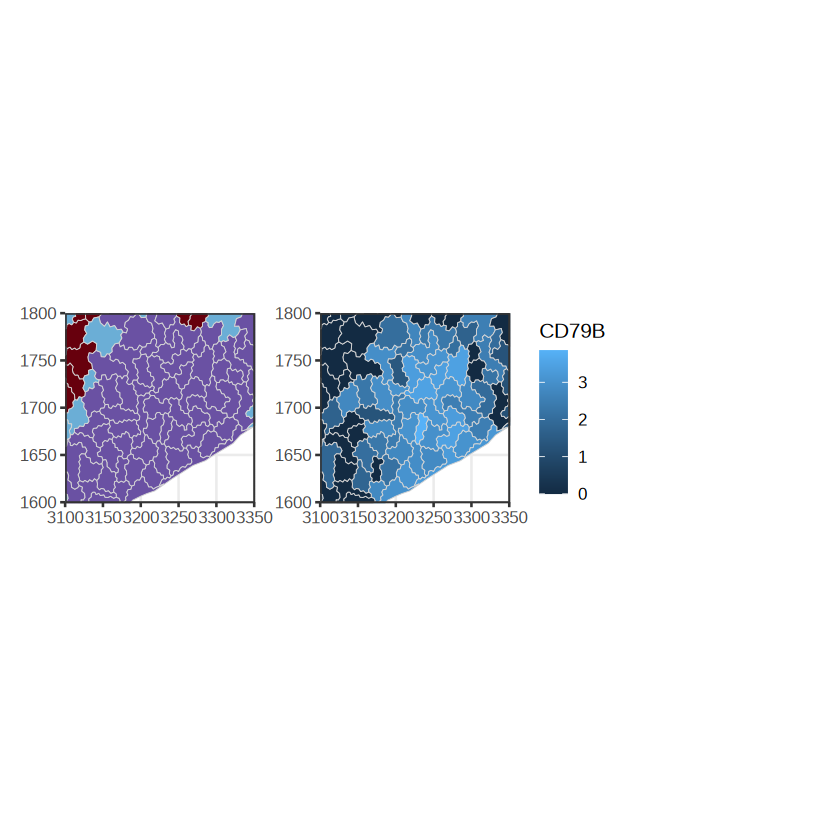

In [31]:
plot_genes_tiles()

ggsave("SuppFig3_2.svg", width=18, height=6)

In [16]:
getwd()

[1] "/data/wei/qq06/xenium/phaseZ_finalize_figs"

In [24]:
plot_genes_tiles_cont <- function(coords=list(xlim=list(c(3250, 3550),c(3100, 3350), c(1900, 2100), c(1000, 1200)),
                                         ylim=list(c(1800, 2150), c(1600, 1800), c(1400, 1600), c(1000, 1150))),
                             genes=c("PODXL", "CD3E", "COL5A1", "CALB1")) {
    p20 = ggplot() +
        geom_sf(data = as_tibble(imm.niche@meta.data, niche_label=imm.niche$niche_label_fine)%>% filter(patient_id==cont),
                aes(geometry = shape, fill = niche_label), color = 'lightgray') + theme_bw(base_size=12)+theme_void() + scale_fill_manual(values=niche_cols)+ theme(aspect.ratio = 1, legend.position = 'none')+
        coord_sf(xlim=coords$xlim[[1]], ylim=coords$ylim[[1]], expand = FALSE)
    fig2c1a = p20

    feature = genes[1]
    fig2c1 = ggplot() +
        geom_sf(data = cbind(imm.niche@meta.data, FetchData(imm.niche, feature))%>% filter(patient_id==cont),
                aes(geometry = shape, fill = !!sym(feature)), color = 'lightgray') + theme_bw(base_size=12)+theme_void()+
        coord_sf(xlim=coords$xlim[[1]], ylim=coords$ylim[[1]], expand = FALSE) +
        theme(aspect.ratio = 1, legend.position = 'right')

    p20 = ggplot() +
        geom_sf(data = as_tibble(imm.niche@meta.data, niche_label=imm.niche$niche_label_fine)%>% filter(patient_id==cont),
                aes(geometry = shape, fill = niche_label), color = 'lightgray') + theme_bw(base_size=12)+theme_void() + scale_fill_manual(values=niche_cols)+ theme(aspect.ratio = 1, legend.position = 'none')+
        coord_sf(xlim=coords$xlim[[2]], ylim=coords$ylim[[2]], expand = FALSE)
    fig2c1b = p20

    feature = genes[2]
    fig2c3 = ggplot() +
        geom_sf(data = cbind(imm.niche@meta.data, FetchData(imm.niche, feature))%>% filter(patient_id==cont),
                aes(geometry = shape, fill = !!sym(feature)), color = 'lightgray') + theme_bw(base_size=12)+theme_void()+
        coord_sf(xlim=coords$xlim[[2]], ylim=coords$ylim[[2]], expand = FALSE) + theme(aspect.ratio=1, legend.position = 'right')


    p20 = ggplot() +
        geom_sf(data = as_tibble(imm.niche@meta.data, niche_label=imm.niche$niche_label_fine)%>% filter(patient_id==cont),
                aes(geometry = shape, fill = niche_label), color = 'lightgray') + theme_bw(base_size=12)+theme_void() + scale_fill_manual(values=niche_cols)+ theme(aspect.ratio = 1, legend.position = 'none')+
        coord_sf(xlim=coords$xlim[[3]], ylim=coords$ylim[[3]], expand = FALSE)
    fig2c1c = p20

    feature = genes[3]
    fig2c2 = ggplot() +
        geom_sf(data = cbind(imm.niche@meta.data, FetchData(imm.niche, feature))%>% filter(patient_id==cont),
                aes(geometry = shape, fill = !!sym(feature)), color = 'lightgray') + theme_bw(base_size=12)+ theme_void()+
        coord_sf(xlim=coords$xlim[[3]], ylim=coords$ylim[[3]], expand = FALSE) +theme(aspect.ratio = 1, legend.position = 'right')

    p20 = ggplot() +
        geom_sf(data = as_tibble(imm.niche@meta.data, niche_label=imm.niche$niche_label_fine)%>% filter(patient_id==cont),
                aes(geometry = shape, fill = niche_label), color = 'lightgray') + theme_bw(base_size=12)+theme_void() + scale_fill_manual(values=niche_cols)+
        coord_sf(xlim=coords$xlim[[4]], ylim=coords$ylim[[4]], expand = FALSE)+ theme(aspect.ratio = 1, legend.position = 'none')
    fig2c1d = p20

  
    feature = 'SCNN1G'
    fig2c4 = ggplot() +
        geom_sf(data = cbind(imm.niche@meta.data, FetchData(imm.niche, feature))%>% filter(patient_id==cont),
                aes(geometry = shape, fill = !!sym(feature)), color = 'lightgray') + theme_bw(base_size=12)+theme_void()+
        coord_sf(xlim=coords$xlim[[4]], ylim=coords$ylim[[4]], expand = FALSE) +
        theme(aspect.ratio = 1, legend.position = 'right')
    (fig2c1a | fig2c1 | plot_spacer()) / (fig2c1c|fig2c2|plot_spacer()) / (fig2c1d|fig2c4|plot_spacer())
}

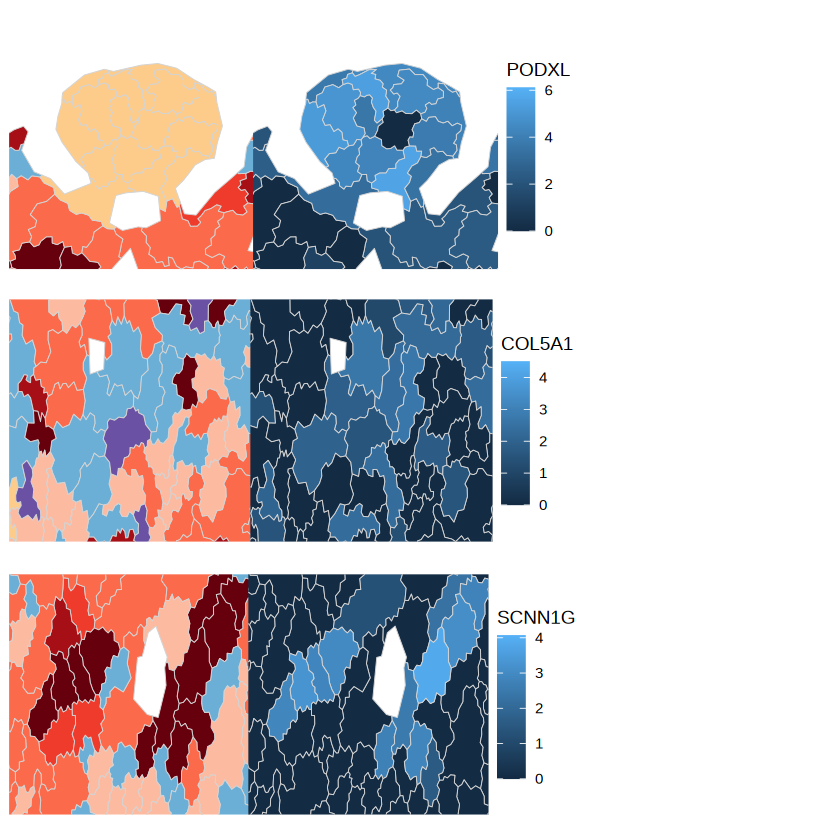

In [30]:
plot_genes_tiles_cont(coords=list(xlim=list(c(2500, 2800),c(3000, 3350), c(3600, 4000), c(2100, 2500)),
                                  ylim=list(c(1300, 1600),c(900, 1100), c(1000, 1220), c(1000, 1200))))

ggsave("SuppFig3_3.svg", width=18, height=18)